In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score

In [3]:
# A.Loading the file
df = pd.read_csv("diabetes.csv")

df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
# Checking the upper set of data
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
# Checking the lower set of data
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [6]:
# B.Mathematical analysis of data(Mean, , Minimum, Maximum, Count, Standard deviation)
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
# Checking the information in given deta-set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [16]:
# Checking the shape of the data
print("Rows and Columns:", df.shape)

Rows and Columns: (768, 9)


In [12]:
# Checking missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

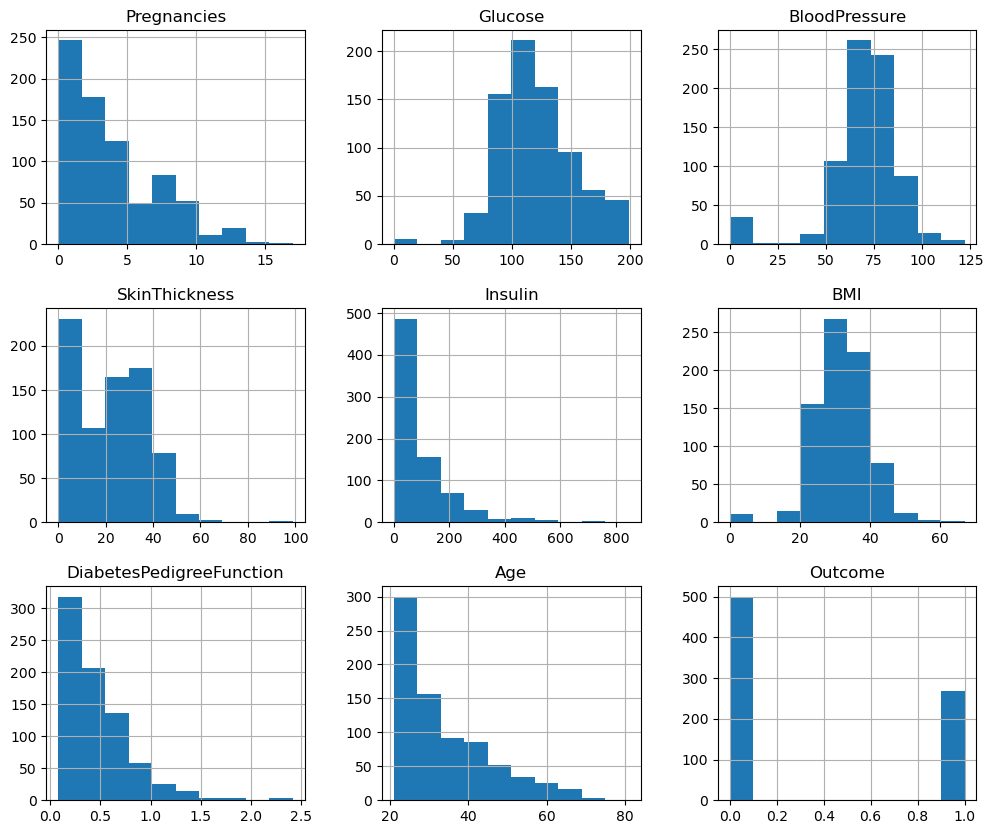

In [13]:
# C.Histogram
df.hist(figsize=(12,10))
plt.show()

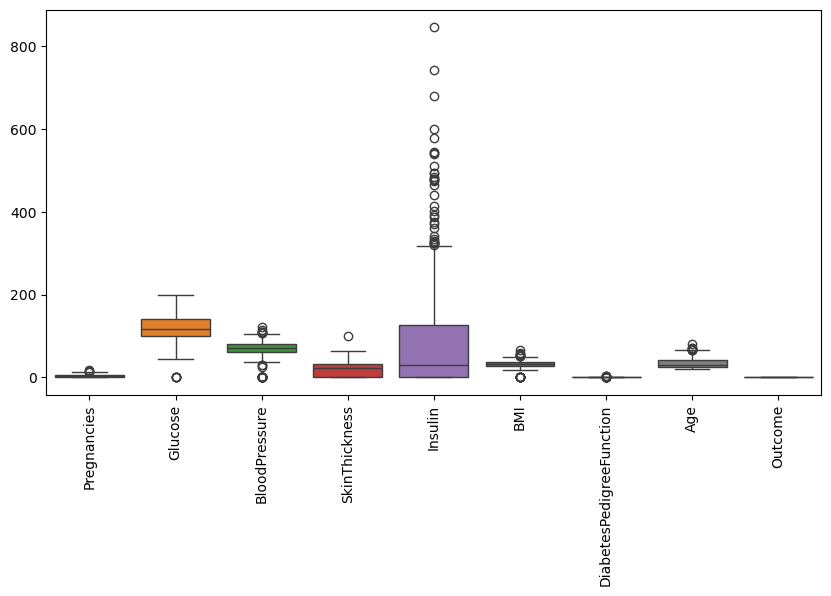

In [14]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.show()

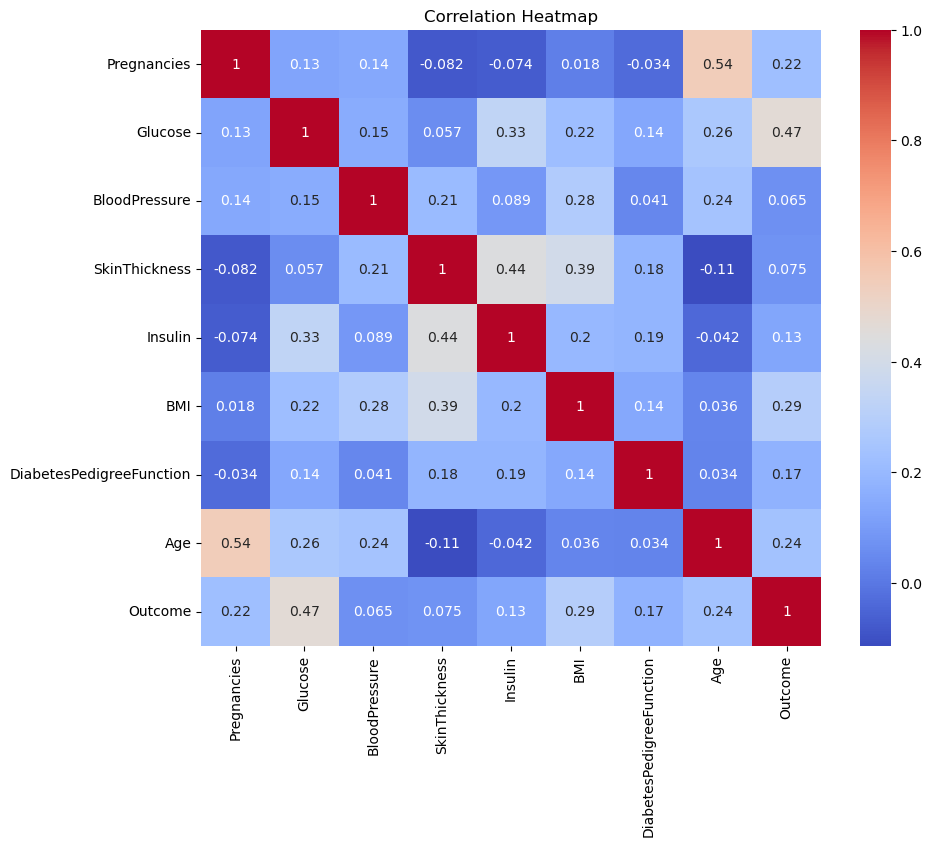

In [17]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

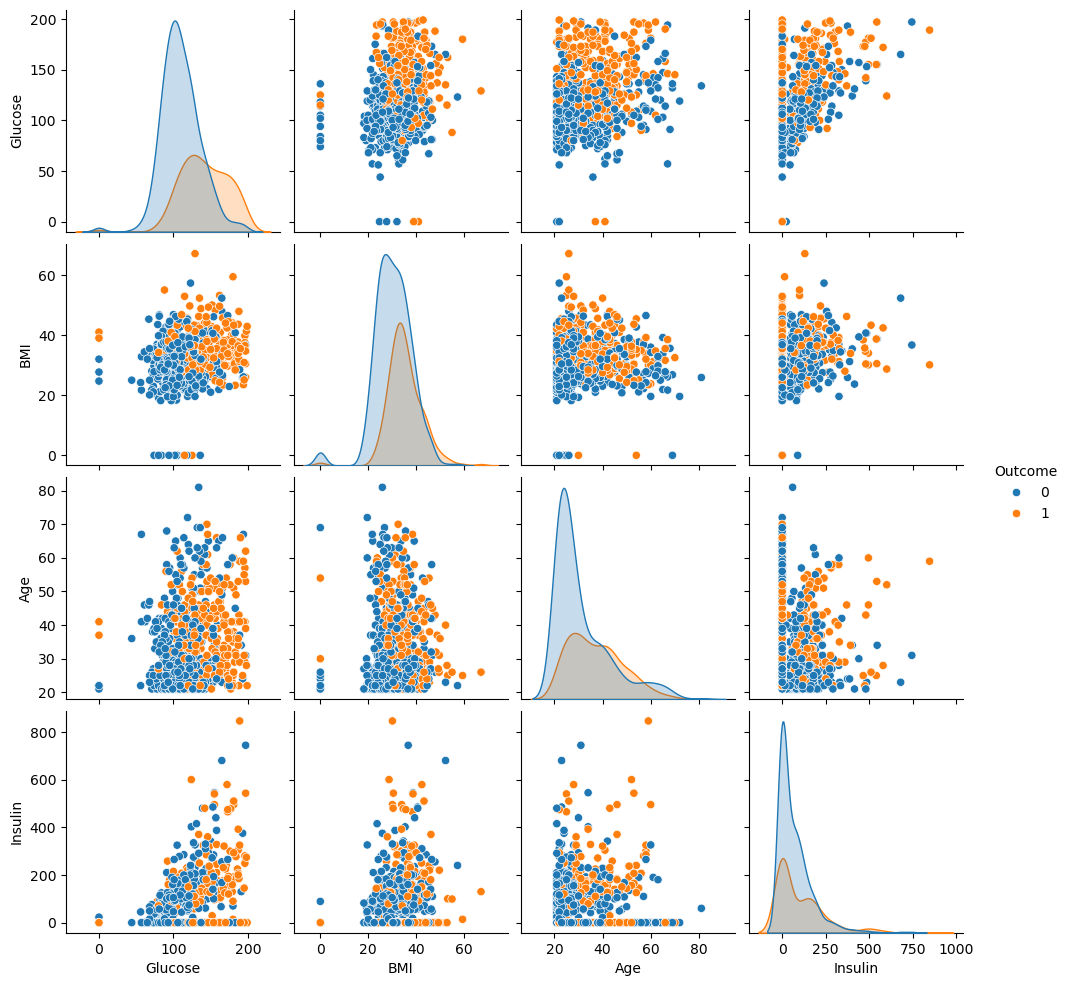

In [18]:
sns.pairplot(df[['Glucose',
                 'BMI',
                 'Age',
                 'Insulin',
                 'Outcome']],
             hue='Outcome')

plt.show()

In [19]:
cols = ['Glucose',
        'BloodPressure',
        'SkinThickness',
        'Insulin',
        'BMI']

df[cols] = df[cols].replace(0,np.nan)

In [20]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [21]:
df.fillna(df.median(), inplace=True)

In [22]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [23]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [27]:
y_pred = model.predict(X_test)

In [28]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy =", accuracy)

Accuracy = 0.7532467532467533


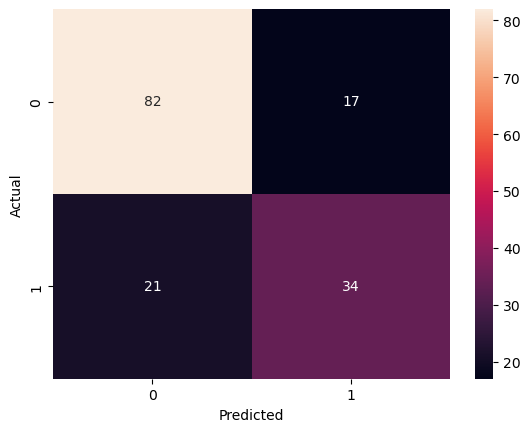

In [29]:
cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [30]:
y_prob = model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test,y_prob)

print("ROC AUC Score =", auc)

ROC AUC Score = 0.8211202938475666


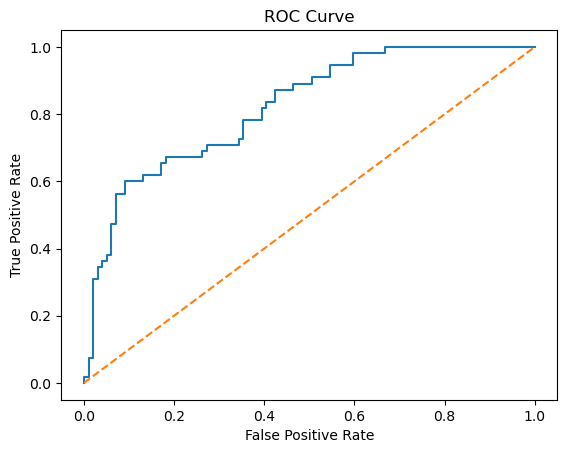

In [31]:
fpr, tpr, threshold = roc_curve(y_test,
                                y_prob)

plt.plot(fpr,tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [34]:
coef = pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_[0]
})

coef.sort_values(by="Coefficient",
                 ascending=False)

,Feature,Coefficient
6,DiabetesPedigreeFunction,0.553781
5,BMI,0.101787
0,Pregnancies,0.067620
1,Glucose,0.037336
7,Age,0.034602
3,SkinThickness,0.007708
4,Insulin,-0.001668
2,BloodPressure,-0.013231


In [35]:
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Save model
pickle.dump(model, open("diabetes_model.pkl", "wb"))

print("Model saved successfully!")

Model saved successfully!


In [ ]:
Precision measures how many of the predicted positive cases are actually positive.

Formula:

Precision=
TP+FP
TP
	​


Where:

TP = True Positives
FP = False Positives

Recall measures how many of the actual positive cases are correctly identified by the model.

Formula:

Recall=
TP+FN
TP
	​


Where:

TP = True Positives
FN = False Negatives

In this diabetes prediction assignment:

Precision tells us how many patients predicted as diabetic are actually diabetic.
Recall tells us how many diabetic patients were correctly identified by the model.

A high recall is important in healthcare because missing a diabetic patient may lead to serious health problems.

In [ ]:
Precision measures how many of the predicted positive cases are actually positive.

Formula:

Precision=
TP+FP
TP
	​


Where:

TP = True Positives
FP = False Positives

Recall measures how many of the actual positive cases are correctly identified by the model.

Formula:

Recall=
TP+FN
TP
	​


Where:

TP = True Positives
FN = False Negatives

In this diabetes prediction assignment:

Precision tells us how many patients predicted as diabetic are actually diabetic.
Recall tells us how many diabetic patients were correctly identified by the model.

A high recall is important in healthcare because missing a diabetic patient may lead to serious health problems.

## Interview questions

### 1. What is the difference between precision and recall?


Precision measures how many of the predicted positive cases are actually positive.

Formula:

Precision=
TP+FP
TP
	​


Where:

TP = True Positives
FP = False Positives

Recall measures how many of the actual positive cases are correctly identified by the model.

Formula:

Recall=
TP+FN
TP
	​


Where:

TP = True Positives
FN = False Negatives

In this diabetes prediction assignment:

Precision tells us how many patients predicted as diabetic are actually diabetic.
Recall tells us how many diabetic patients were correctly identified by the model.

A high recall is important in healthcare because missing a diabetic patient may lead to serious health problems.

### 2. What is cross-validation, and why is it important in binary classification?

Cross-validation is a technique used to evaluate the performance of a machine learning model by dividing the dataset into multiple parts (folds).

In K-Fold Cross Validation, the dataset is split into K equal parts. The model is trained on K−1 folds and tested on the remaining fold. This process is repeated K times and the average performance is calculated.

Importance in Binary Classification:

It provides a more reliable estimate of model performance.
It reduces the risk of overfitting.
It ensures that every data point is used for both training and testing.
It helps in selecting the best model for classification tasks.

In this diabetes prediction assignment:
Cross-validation helps verify that the Logistic Regression model performs consistently in predicting whether a patient is diabetic (1) or non-diabetic (0), rather than giving good results only on one train-test split.
